# Gold Prediction with LSTM and Sentiment Analysis
Author: Rahma A S

## 1. Introduction

This notebook explores gold price prediction using LSTM models and incorporates sentiment analysis from financial news to improve forecasting accuracy. I utilize historical gold price data from Yahoo Finance in 2 years period (2015-2016) and news headlines and contents matched with the gold price period for this purpose.

## 2. Data Loading


### Install Libraries

In [1]:
!pip install yfinance

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os
import yfinance as yf

### Load Gold Data

In [2]:
# Download all OHLCV data (Open, High, Low, Close, Volume)
raw_data = yf.download('GC=F', start='2015-01-01', end='2016-12-31')
df = pd.DataFrame(raw_data['Close']).rename(columns={'GC=F':'Gold_Close'})

/tmp/ipykernel_4657/2021337633.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download('GC=F', start='2015-01-01', end='2016-12-31')
[*********************100%***********************]  1 of 1 completed


In [3]:
df.tail()

Ticker,Gold_Close
Date,
2016-12-23,1131.900024
2016-12-27,1137.300049
2016-12-28,1139.400024
2016-12-29,1156.400024
2016-12-30,1150.000000


### Load Sentiment Analysis Data

In [4]:
from google.colab import files
uploaded = files.upload()

Saving sent_15_16_ready.csv to sent_15_16_ready (1).csv


In [5]:
import pandas as pd

In [6]:
df_sent = pd.read_csv("sent_15_16_ready.csv")  # change to your file name
df_sent.head()

,Date_Only,sentiment
0,2015-01-01,0
1,2015-01-02,0
2,2015-01-03,0
3,2015-01-04,0
4,2015-01-05,0


In [7]:
df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
df_sent.set_index('Date_Only', inplace=True)

## 3. Data Preprocessing and Cleaning

For gold price data, the initial preprocessing involved sorting the data by date and dropping any rows with missing values. To handle missing dates (e.g., weekends or holidays where gold prices are not recorded), the DataFrame was reindexed to include all days within the date range, and the `Gold_Close` column was then filled using linear interpolation. This approach is supported by research, such as Moken et al. (2025), who found that linear interpolation consistently yielded the lowest mean MAE, reducing error by 23.9% compared to no interpolation, and improved mean R2 by 1.15%.

For the sentiment analysis data, the 'Date_Only' column was converted to datetime objects and set as the DataFrame's index to ensure proper time series alignment.

### Gold Data

In [8]:
df = df.sort_index()
df = df.dropna()

In [9]:
all_days = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df_7day = df.reindex(all_days)

df_7day['Gold_Close'] = df_7day['Gold_Close'].interpolate(method='linear')

In [10]:
prices = df_7day['Gold_Close'].values.reshape(-1, 1)
dates = df_7day.index.values

### Sentiment Analysis Data
The preprocessing of the sentiment analysis is provided in different notebook, "Sentiment Analysis Data Preprocessing". So this section can be skipped here. Initially, I used FinGPT and  GPT-mini to generate the sentiment analysis from financial news. At the end, GPT-mini generated sentiment analysis is chosen since it performed better despite that it is general purpose model, surpassed FinGPT which has focused the goal in financial.

## 4. Exploratory Data Analysis (EDA)



Gold Data - Descriptive Statistics:
count     729.000000
mean     1203.906723
std        79.516927
min      1050.800049
25%      1141.300049
50%      1201.666707
75%      1263.900024
max      1364.900024
Name: Gold_Close, dtype: float64


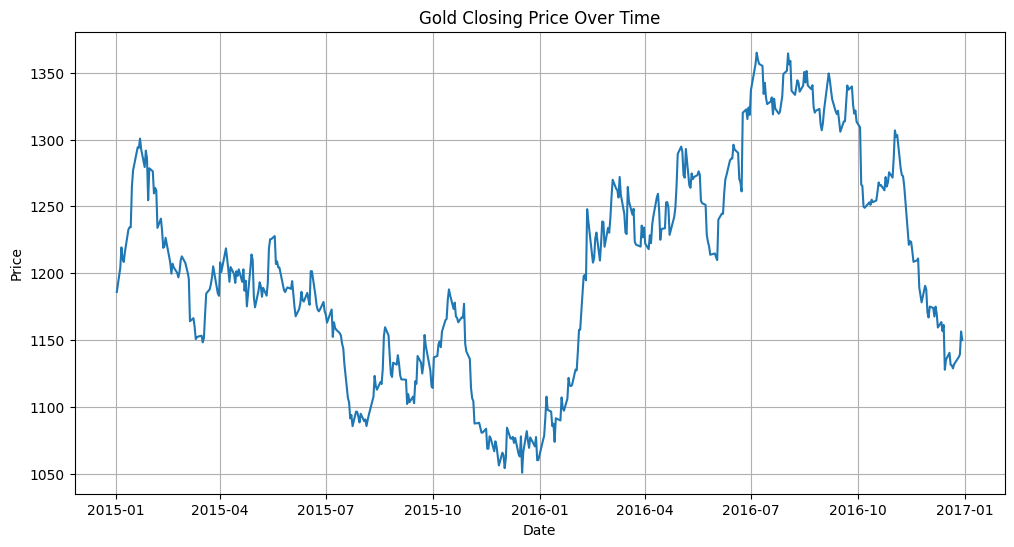


Sentiment Data - Value Counts:
sentiment
 0    680
-1     28
 1     23
Name: count, dtype: int64


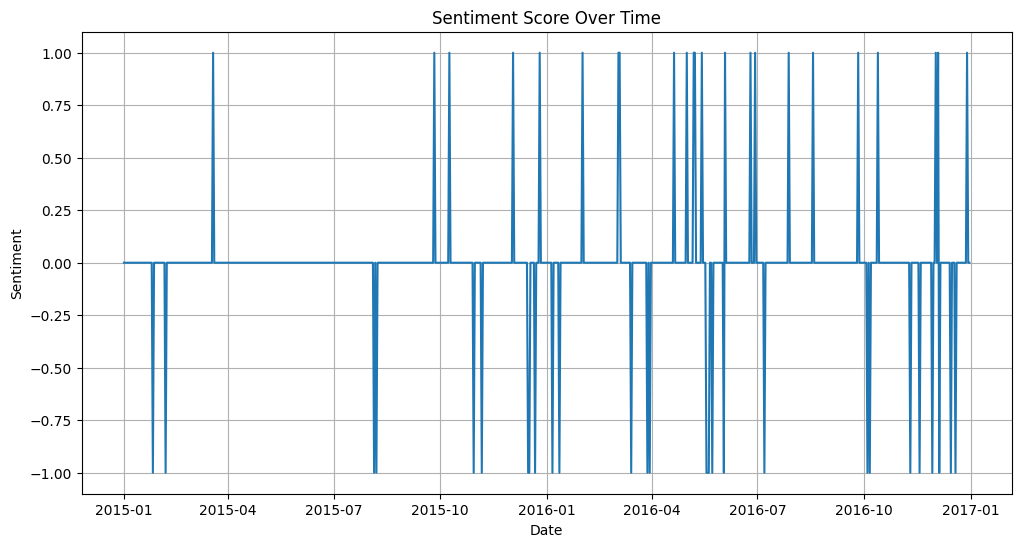

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- EDA for Gold Data ---

print("\nGold Data - Descriptive Statistics:")
print(df_7day['Gold_Close'].describe())

plt.figure(figsize=(12, 6))
plt.plot(df_7day.index, df_7day['Gold_Close'])
plt.title('Gold Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# --- EDA for Sentiment Analysis Data ---

print("\nSentiment Data - Value Counts:")
print(df_sent['sentiment'].value_counts())

plt.figure(figsize=(12, 6))
plt.plot(df_sent.index, df_sent['sentiment'])
plt.title('Sentiment Score Over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment')
plt.grid(True)
plt.show()



Correlation between Gold Price and Sentiment:
            Gold_Close  sentiment
Gold_Close     1.00000    0.07226
sentiment      0.07226    1.00000


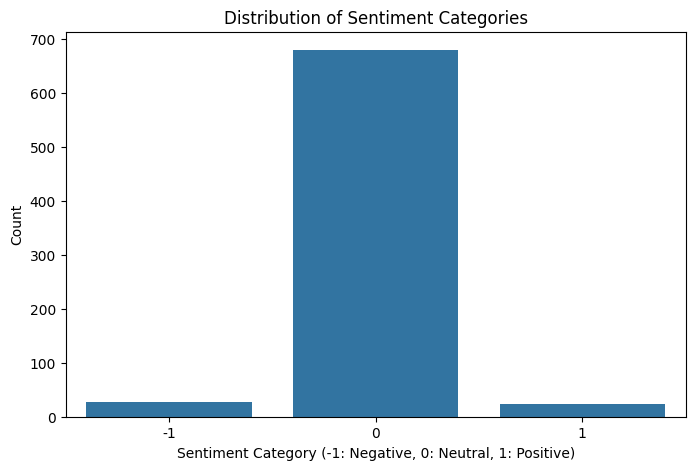

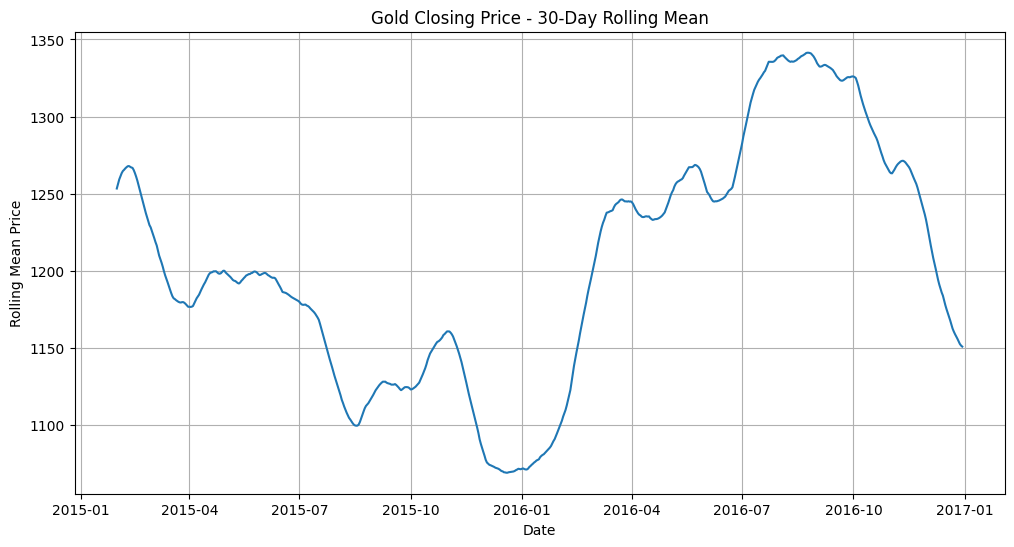

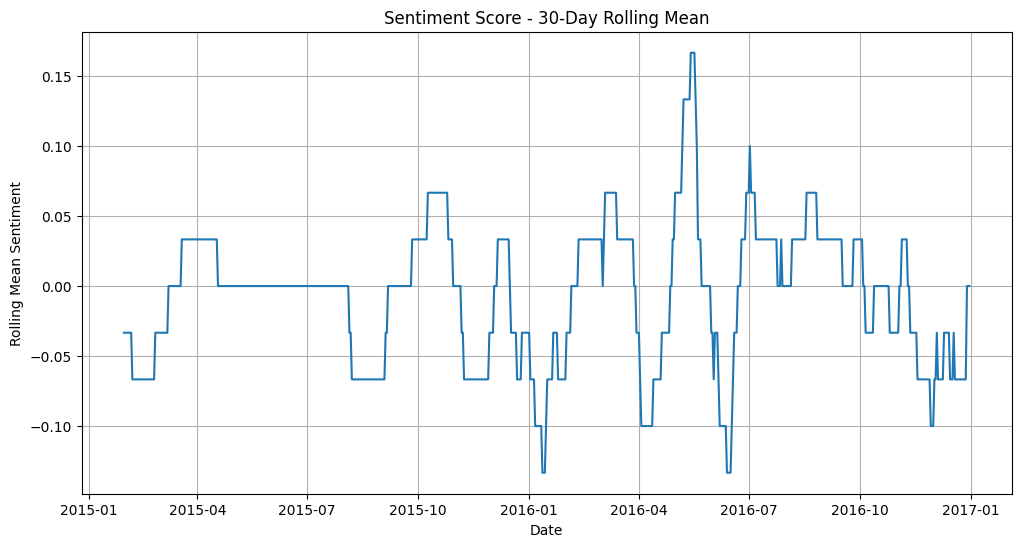

In [12]:
# 1. Merge dataframes for correlation analysis
merged_df = pd.merge(df_7day, df_sent, left_index=True, right_index=True, how='inner')

print("\nCorrelation between Gold Price and Sentiment:")
print(merged_df[['Gold_Close', 'sentiment']].corr())

# 2. Visualize Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df_sent)
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment Category (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('Count')
plt.show()

# 3. Rolling Mean of Gold Prices
plt.figure(figsize=(12, 6))
plt.plot(df_7day.index, df_7day['Gold_Close'].rolling(window=30).mean())
plt.title('Gold Closing Price - 30-Day Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Rolling Mean Price')
plt.grid(True)
plt.show()

# 4. Rolling Mean of Sentiment Scores
plt.figure(figsize=(12, 6))
plt.plot(df_sent.index, df_sent['sentiment'].rolling(window=30).mean())
plt.title('Sentiment Score - 30-Day Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Rolling Mean Sentiment')
plt.grid(True)
plt.show()


Correlation between Gold Price and Sentiment: The correlation coefficient between 'Gold_Close' and 'sentiment' is approximately 0.072, which indicates a very weak positive linear relationship. This suggests that while there might be a slight tendency for gold prices to increase as sentiment becomes more positive, the relationship is not strong.

Sentiment Distribution: The countplot visualizes the distribution of sentiment categories. It shows that the majority of sentiment scores are '0' (neutral), with fewer '-1' (negative) and '1' (positive) sentiments.

Rolling Means: The plots of the 30-day rolling mean for both Gold Prices and Sentiment Scores help in visualizing the underlying trends and smoothing out short-term fluctuations in the data. This allows for a clearer view of longer-term patterns.

## 5. Methodology and Model Building

This section details the methodology for preparing the data and building the Long Short-Term Memory (LSTM) models for gold price prediction. The core steps involve creating sliding windows for time series data, splitting the dataset into training, validation, and test sets, scaling the gold price data, and defining the LSTM model architecture.

### Data Preparation for LSTM

To prepare the time series data for the LSTM models, a `create_windows` function is used. This function generates sequences (windows) of a specified size from the combined features (gold prices and sentiment). For each window, the corresponding target is the gold price at the next time step. This process transforms the flat time series data into a supervised learning format suitable for LSTMs, where `X` contains input sequences and `y` contains the respective next-step gold prices.

### Data Splitting and Scaling

1.  **Initial Split**: The merged dataframe (`merged_df`), which contains both gold prices and sentiment scores, is first split into training (85%) and test (15%) sets to ensure that the test set is unseen during training and validation.
2.  **Scaling**: Gold closing prices (`Gold_Close`) are scaled using `MinMaxScaler` to normalize the data between 0 and 1. This is a crucial step for neural networks like LSTMs, as it helps in faster convergence and prevents issues with differing scales of features. Sentiment values, already ranging from -1 to 1, are directly incorporated without further scaling.
3.  **Feature Combination**: The scaled gold prices and sentiment values are combined into a single feature matrix, allowing the `create_windows` function to generate input sequences that include both types of data.
4.  **Window Creation**: The `create_windows` function then processes this feature matrix to create `X` (input sequences) and `y` (target gold prices).
5.  **Final Splits**: The generated `X` and `y` are further split. The training set is divided into a training subset (85%) and a validation subset (15%) to monitor model performance during training and prevent overfitting. This results in `X_train_merged`, `X_val_merged`, `X_test_merged` for the model including sentiment, and `X_train_gold`, `X_val_gold`, `X_test_gold` for the gold-only model (by dropping the sentiment column).

### Model Building

Two separate LSTM models are constructed using the `build_lstm_model` function:

1.  **Gold Data Only Model**: This model takes only historical gold prices as input. Its `input_shape` is `(window_size, 1)`, reflecting sequences of gold prices.
2.  **Gold Data with Sentiment Analysis Model**: This model integrates both historical gold prices and sentiment scores. Its `input_shape` is `(window_size, 2)`, representing sequences of gold prices and sentiment scores.

Both models share the same architecture:

*   **Three LSTM Layers**: Each with 50 units. The first two layers have `return_sequences=True` to pass the full sequence output to the next LSTM layer, while the third LSTM layer has `return_sequences=False`, outputting only the last time step's hidden state.
*   **Dense Output Layer**: A final `Dense` layer with 1 unit is used to predict the single output value (the next day's gold price).

**Compilation**: Both models are compiled with the 'adam' optimizer and 'mean squared error' (MSE) as the loss function, which is suitable for regression tasks like price prediction.

### Model Training

Each model is trained separately using its respective dataset (gold-only or gold+sentiment). `ModelCheckpoint` is used to save the best model weights based on validation loss, and `EarlyStopping` with a patience of 10 epochs is employed to halt training if the validation loss does not improve, preventing overfitting and ensuring that the best performing model is retained.

### Splitting Data

In [13]:
def create_windows(data, target_col_idx, window_size=8):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size, :]) # All columns (Price & Sentiment)
        y.append(data[i + window_size, target_col_idx]) # Only Price
    return np.array(X), np.array(y)

In [14]:
# Split raw data 85/15 first to prevent leakage
split_idx = int(len(merged_df) * 0.85)
train_df_merged = merged_df.iloc[:split_idx]

# Scaler for Price only
scaler_price = MinMaxScaler(feature_range=(0, 1))
scaler_price.fit(train_df_merged[['Gold_Close']])

MinMaxScaler()

In [15]:
# Scale the full dataset
prices_scaled = scaler_price.transform(merged_df[['Gold_Close']])
sentiment_values = merged_df['sentiment'].values.reshape(-1, 1) # Already -1 to 1

# Combine into one feature matrix (N, 2)
features_scaled = np.hstack((prices_scaled, sentiment_values))

In [16]:
# features_scaled: col 0 is Price, col 1 is Sentiment
X, y = create_windows(features_scaled, target_col_idx=0, window_size=8)

# Final Splits
train_val_idx = int(len(X) * 0.85)
X_train_val, y_train_val = X[:train_val_idx], y[:train_val_idx]
X_test_merged, y_test = X[train_val_idx:], y[train_val_idx:]

# Split Train/Val (85/15)
v_idx = int(len(X_train_val) * 0.85)
X_train_merged, y_train = X_train_val[:v_idx], y_train_val[:v_idx]
X_val_merged, y_val = X_train_val[v_idx:], y_train_val[v_idx:]

#Drop the sentiment analysis column for the gold only data
X_train_gold = X_train_merged[:, :, :1]
X_val_gold = X_val_merged[:, :, :1]
X_test_gold = X_test_merged[:, :, :1]


In [17]:
X_train_merged.shape[2]

2

### Model Building

In [18]:
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(50, input_shape=input_shape, return_sequences=True),
        LSTM(50, return_sequences=True),
        LSTM(50, return_sequences=False), # Essential for (samples, 1) output
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Define input shapes for the two models
input_shape_gold_only = (X_train_gold.shape[1], X_train_gold.shape[2]) # (window_size, 1)
input_shape_merged = (X_train_merged.shape[1], X_train_merged.shape[2]) # (window_size, 2)

# Build the two models
model_gold_only = build_lstm_model(input_shape_gold_only)
model_gold_sentiment = build_lstm_model(input_shape_merged)

print("Model for Gold Data Only:")
model_gold_only.summary()

print("\nModel for Gold Data with Sentiment Analysis:")
model_gold_sentiment.summary()


Model for Gold Data Only:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8, 50)          │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 8, 50)          │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 8, 50)          │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,051 (199.42 KB)

 Trainable params: 51,051 (199.42 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [19]:
print("\n--- Training Model for Gold Data Only ---")
checkpoint_gold_only = ModelCheckpoint('best_lstm_gold_only.h5', monitor='val_loss', save_best_only=True, verbose=1)
early_stop_gold_only = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_gold_only = model_gold_only.fit(
    X_train_gold, y_train,
    validation_data=(X_val_gold, y_val),
    epochs=100, batch_size=32,
    callbacks=[checkpoint_gold_only, early_stop_gold_only],
    verbose=1
)

print("\n--- Training Model for Gold Data with Sentiment Analysis ---")
checkpoint_gold_sentiment = ModelCheckpoint('best_lstm_gold_sentiment.h5', monitor='val_loss', save_best_only=True, verbose=1)
early_stop_gold_sentiment = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_gold_sentiment = model_gold_sentiment.fit(
    X_train_merged, y_train,
    validation_data=(X_val_merged, y_val),
    epochs=100, batch_size=32,
    callbacks=[checkpoint_gold_sentiment, early_stop_gold_sentiment],
    verbose=1
)



--- Training Model for Gold Data Only ---
Epoch 1/100
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1355
Epoch 1: val_loss improved from None to 0.01235, saving model to best_lstm_gold_only.h5



Epoch 1: finished saving model to best_lstm_gold_only.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.0758 - val_loss: 0.0124
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0141
Epoch 2: val_loss improved from 0.01235 to 0.01059, saving model to best_lstm_gold_only.h5



Epoch 2: finished saving model to best_lstm_gold_only.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0130 - val_loss: 0.0106
Epoch 3/100
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0075
Epoch 3: val_loss improved from 0.01059 to 0.00526, saving model to best_lstm_gold_only.h5



Epoch 3: finished saving model to best_lstm_gold_only.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0067 - val_loss: 0.0053
Epoch 4/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0049
Epoch 4: val_loss did not improve from 0.00526
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0046 - val_loss: 0.0077
Epoch 5/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0049
Epoch 5: val_loss improved from 0.00526 to 0.00406, saving model to best_lstm_gold_only.h5



Epoch 5: finished saving model to best_lstm_gold_only.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 6/100
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0042
Epoch 6: val_loss did not improve from 0.00406
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0042 - val_loss: 0.0045
Epoch 7/100
14/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0044
Epoch 7: val_loss did not improve from 0.00406
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 8/100
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0047
Epoch 8: val_loss improved from 0.00406 to 0.00388, saving model to best_lstm_gold_only.h5


...


Epoch 28: finished saving model to best_lstm_gold_sentiment.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0034 - val_loss: 0.0022
Epoch 29/100
14/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0030
Epoch 29: val_loss did not improve from 0.00222
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 30/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0036
Epoch 30: val_loss did not improve from 0.00222
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0033 - val_loss: 0.0025
Epoch 31/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0029
Epoch 31: val_loss did not improve from 0.00222
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0032 - val_loss: 0.0034
Epoch 32/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0034
Epoch 32: val_loss did not improve from 0.00222
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0030 - val_loss: 0.0055
Epoch 33/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0032
Epoch 33: val_loss did not improve


Epoch 36: finished saving model to best_lstm_gold_sentiment.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 37/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0028
Epoch 37: val_loss did not improve from 0.00200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 38/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0027
Epoch 38: val_loss did not improve from 0.00200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 39/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025
Epoch 39: val_loss did not improve from 0.00200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0024 - val_loss: 0.0060
Epoch 40/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0022
Epoch 40: val_loss did not improve from 0.00200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0025 - val_loss: 0.0091
Epoch 41/100
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0025
Epoch 41: val_loss did not improve


Epoch 43: finished saving model to best_lstm_gold_sentiment.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 44/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024
Epoch 44: val_loss did not improve from 0.00155
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0026 - val_loss: 0.0085
Epoch 45/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024
Epoch 45: val_loss did not improve from 0.00155
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0026 - val_loss: 0.0092
Epoch 46/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0023
Epoch 46: val_loss did not improve from 0.00155
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0021 - val_loss: 0.0025
Epoch 47/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021
Epoch 47: val_loss did not improve from 0.00155
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0021 - val_loss: 0.0039
Epoch 48/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0020
Epoch 48: val_loss improved from 0


Epoch 48: finished saving model to best_lstm_gold_sentiment.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 49/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0020
Epoch 49: val_loss did not improve from 0.00153
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0021 - val_loss: 0.0027
Epoch 50/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0018
Epoch 50: val_loss did not improve from 0.00153
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0018 - val_loss: 0.0035
Epoch 51/100
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022
Epoch 51: val_loss did not improve from 0.00153
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0018 - val_loss: 0.0032
Epoch 52/100
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0019
Epoch 52: val_loss did not improve from 0.00153
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0018 - val_loss: 0.0028
Epoch 53/100
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021
Epoch 53: val_loss did not improve


Epoch 55: finished saving model to best_lstm_gold_sentiment.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 56/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0019
Epoch 56: val_loss did not improve from 0.00152
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 57/100
15/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0020
Epoch 57: val_loss did not improve from 0.00152
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0020 - val_loss: 0.0034
Epoch 58/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017
Epoch 58: val_loss did not improve from 0.00152
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0018 - val_loss: 0.0027
Epoch 59/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016
Epoch 59: val_loss did not improve from 0.00152
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 60/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015
Epoch 60: val_loss did not improve

## 6. Results and Evaluation


### Gold Data Only

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step

--- Evaluation for Gold Data Only ---
Mean Absolute Error (MAE): 16.0682
Mean Squared Error (MSE): 420.8891
Root Mean Squared Error (RMSE): 20.5156


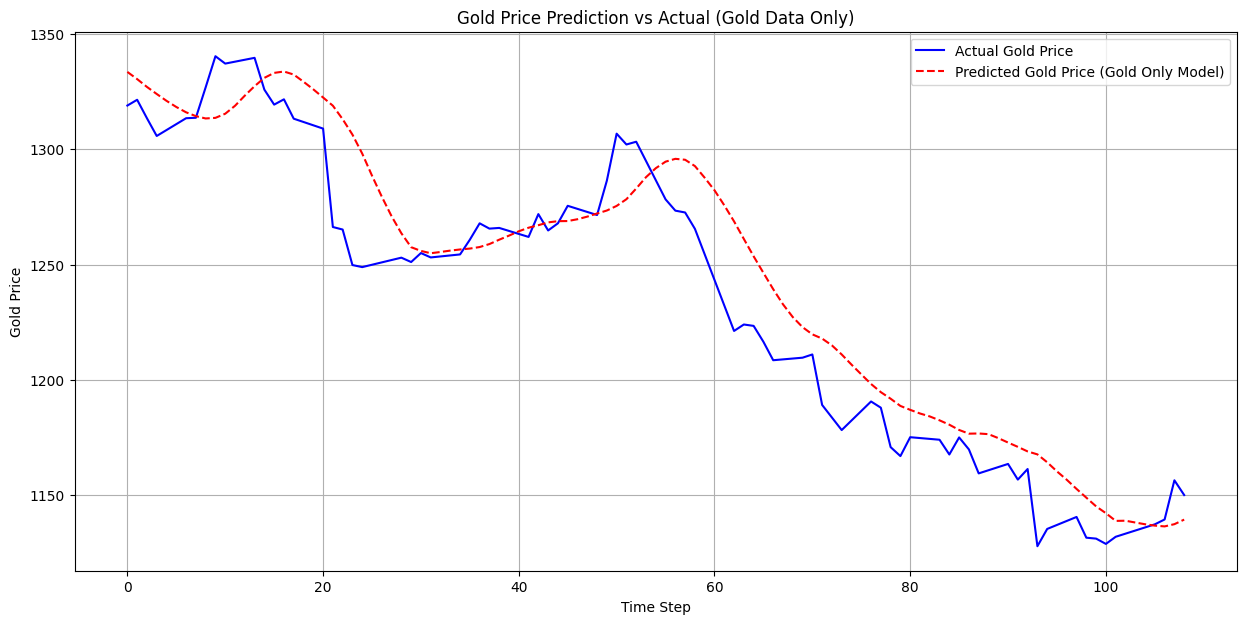

In [20]:
# Load the best model for Gold Data Only
model_gold_only.load_weights('best_lstm_gold_only.h5')

# Make predictions on the test set
y_pred_gold_only_scaled = model_gold_only.predict(X_test_gold)

# Inverse transform the predictions and actual values
y_pred_gold_only = scaler_price.inverse_transform(y_pred_gold_only_scaled)
y_test_actual = scaler_price.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_gold_only = mean_absolute_error(y_test_actual, y_pred_gold_only)
mse_gold_only = mean_squared_error(y_test_actual, y_pred_gold_only)
rmse_gold_only = np.sqrt(mse_gold_only)

print(f"\n--- Evaluation for Gold Data Only ---")
print(f"Mean Absolute Error (MAE): {mae_gold_only:.4f}")
print(f"Mean Squared Error (MSE): {mse_gold_only:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gold_only:.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual, label='Actual Gold Price', color='blue')
plt.plot(y_pred_gold_only, label='Predicted Gold Price (Gold Only Model)', color='red', linestyle='--')
plt.title('Gold Price Prediction vs Actual (Gold Data Only)')
plt.xlabel('Time Step')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()


### Gold Data with Sentiment Analysis

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step

--- Evaluation for Gold Data with Sentiment Analysis ---
Mean Absolute Error (MAE): 9.8468
Mean Squared Error (MSE): 174.4039
Root Mean Squared Error (RMSE): 13.2062


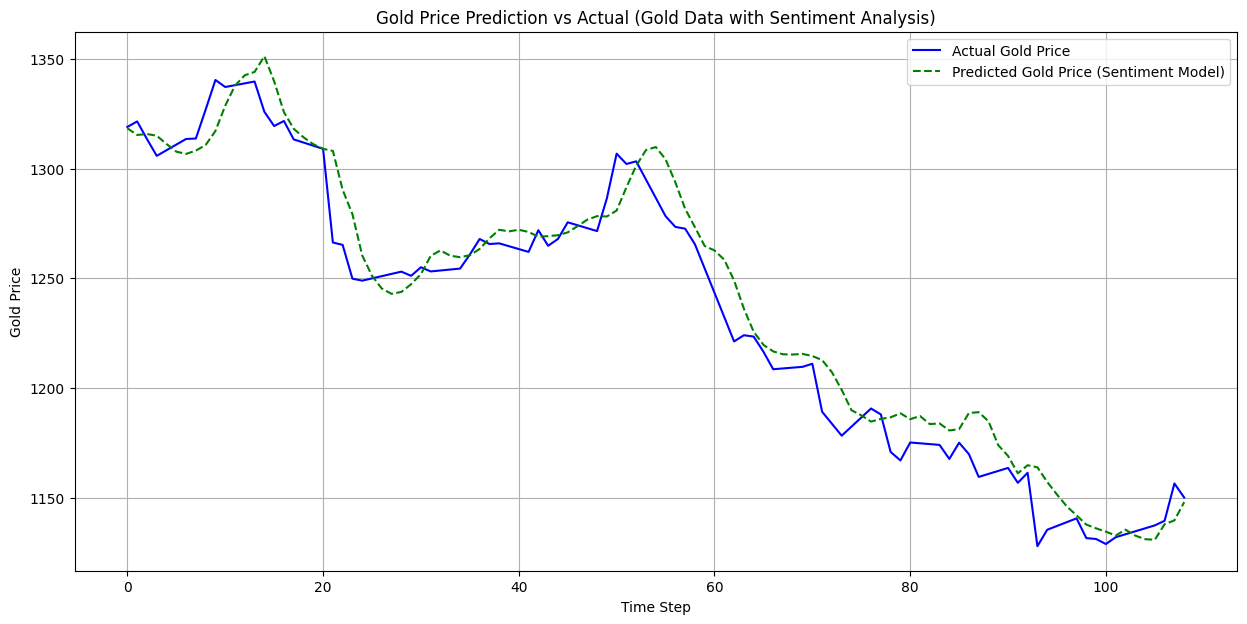

In [21]:
# Load the best model for Gold Data with Sentiment Analysis
model_gold_sentiment.load_weights('best_lstm_gold_sentiment.h5')

# Make predictions on the test set
y_pred_gold_sentiment_scaled = model_gold_sentiment.predict(X_test_merged)

# Inverse transform the predictions and actual values
y_pred_gold_sentiment = scaler_price.inverse_transform(y_pred_gold_sentiment_scaled)
# y_test_actual is already calculated from the previous cell, but we'll ensure it's available
y_test_actual_sentiment = scaler_price.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_gold_sentiment = mean_absolute_error(y_test_actual_sentiment, y_pred_gold_sentiment)
mse_gold_sentiment = mean_squared_error(y_test_actual_sentiment, y_pred_gold_sentiment)
rmse_gold_sentiment = np.sqrt(mse_gold_sentiment)

print(f"\n--- Evaluation for Gold Data with Sentiment Analysis ---")
print(f"Mean Absolute Error (MAE): {mae_gold_sentiment:.4f}")
print(f"Mean Squared Error (MSE): {mse_gold_sentiment:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gold_sentiment:.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual_sentiment, label='Actual Gold Price', color='blue')
plt.plot(y_pred_gold_sentiment, label='Predicted Gold Price (Sentiment Model)', color='green', linestyle='--')
plt.title('Gold Price Prediction vs Actual (Gold Data with Sentiment Analysis)')
plt.xlabel('Time Step')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()


### Side to Side Comparison


--- Model Performance Comparison ---
        Gold Data Only  Gold Data + Sentiment
Metric                                       
MAE          16.068158               9.846764
MSE         420.889117             174.403875
RMSE         20.515582              13.206206


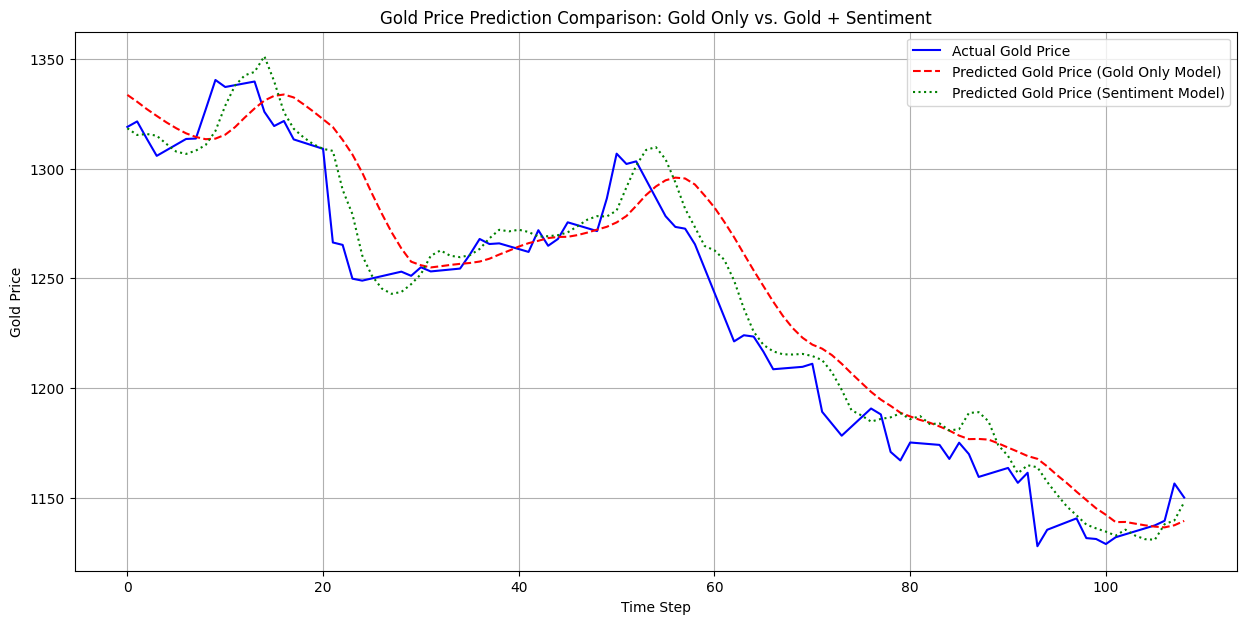

In [26]:
print("\n--- Model Performance Comparison ---")
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE'],
    'Gold Data Only': [mae_gold_only, mse_gold_only, rmse_gold_only],
    'Gold Data + Sentiment': [mae_gold_sentiment, mse_gold_sentiment, rmse_gold_sentiment]
})
print(comparison_df.set_index('Metric'))

# Visualize predictions from both models vs actual
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual, label='Actual Gold Price', color='blue')
plt.plot(y_pred_gold_only, label='Predicted Gold Price (Gold Only Model)', color='red', linestyle='--')
plt.plot(y_pred_gold_sentiment, label='Predicted Gold Price (Sentiment Model)', color='green', linestyle=':')
plt.title('Gold Price Prediction Comparison: Gold Only vs. Gold + Sentiment')
plt.xlabel('Time Step')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()

It appears that the model incorporating Sentiment Analysis (RMSE: 13.2062) performed significantly better than the Gold Data Only model (RMSE: 20.5156). This suggests that including sentiment data, even with a weak correlation, contributed to a substansial improvement in prediction accuracy .Visually, both models tend to follow the general trend of the actual gold prices. The plots show how well each model captures the fluctuations, and a closer look at areas where predictions diverge can provide further insights into their strengths and weaknesses.


## 7. Conclusion

This notebook explored gold price prediction using two LSTM models: one utilizing only historical gold price data, and another incorporating sentiment analysis from financial news.

### Model Performance Summary:

| Metric | Gold Data Only | Gold Data + Sentiment |
|---|---|---|
| MAE | 16.068 | 9.847 |
| MSE | 420.889 | 174.404 |
| RMSE | 20.516 | 13.206 |

### Key Findings:

The model including **Sentiment Analysis** (RMSE: 13.206) performed **significantly better** than the **Gold Data Only** model (RMSE: 20.516). This substantial improvement in prediction accuracy, particularly in terms of Root Mean Squared Error, suggests that even with a weak correlation (approximately 0.072) observed during EDA, sentiment data provides a valuable signal for gold price forecasting. The sentiment-enhanced model significantly reduced the average magnitude of errors, making it a more reliable predictor. The visualizations further confirmed that both models generally followed the actual gold price trends, with the sentiment-enhanced model showing a notably better fit to the actual prices.

## 8. References


https://easychair.org/publications/preprint/FvJX

https://arxiv.org/pdf/2411.12748

https://arxiv.org/pdf/2407.16150

https://ieeexplore.ieee.org/document/11320713


